<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.4 MB/s eta 0:00:00


In [ ]:
fasta_text = """>Gene1
ATCGATCGATCGATCGATCGATCGATCGATCGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCT
>Gene2
ATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGAT
>Gene3
ATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGAT
"""
with open("gene.fasta","w") as file:
  file.write(fasta_text)
print("FASTA file created")

FASTA file created


In [ ]:
sequences ={}
with open("gene.fasta") as file:
  gene_name=""
  for line in file:
    line =line.strip()
    if(line.startswith(">")):
      gene_name=line[1:]
      sequences[gene_name]=""
    else:
      sequences[gene_name]+= line
  print(sequences)

{'Gene1': 'ATCGATCGATCGATCGATCGATCGATCGATCGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCT', 'Gene2': 'ATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGAT', 'Gene3': 'ATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGAT'}


In [ ]:
#prints the last gene name
{gene_name:sequences[gene_name]}


{'Gene3': 'ATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGAT'}

In [ ]:
for gene,seq in sequences.items():
  length = len(seq)
  print(gene,length)

Gene1 66
Gene2 58
Gene3 74


In [ ]:
def gc_content(sequence):
  g=sequence.count("G")
  c=sequence.count("C")
  gc=((g+c)/len(sequence))*100
  return round(gc,2)




In [ ]:
print(gc_content(sequences["Gene2"]))

In [ ]:
def at_content(sequence):
  a=sequence.count("A")
  t=sequence.count("T")
  at=((a+t)/len(sequence))*100
  return round(at,2)

In [ ]:
print(at_content(sequences["Gene2"]))

51.72


In [ ]:
from collections import Counter
def dinucleotide_freq(sequence):
  dinucs =[]
  for i in range(len(sequence)-1):
    dinucs.append(sequence[i:i+2])
  return Counter(dinucs)


In [ ]:
print(sequences["Gene1"])
dinucleotide_freq(sequences["Gene1"])

ATCGATCGATCGATCGATCGATCGATCGATCGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCT


Counter({'AT': 8,
         'TC': 8,
         'CG': 8,
         'GA': 7,
         'GC': 9,
         'CT': 9,
         'TA': 8,
         'AG': 8})

In [ ]:
import pandas as pd
results = []
for gene,seq in sequences.items():
  results.append([gene,len(seq),at_content(seq),gc_content(seq)])

  dashboard = pd.DataFrame(results,
                           columns=["Gene","Length","AT %","GC %"])
dashboard

,Gene,Length,AT %,GC %
0,Gene1,66,50.00,50.00
1,Gene2,58,51.72,48.28
2,Gene3,74,51.35,48.65


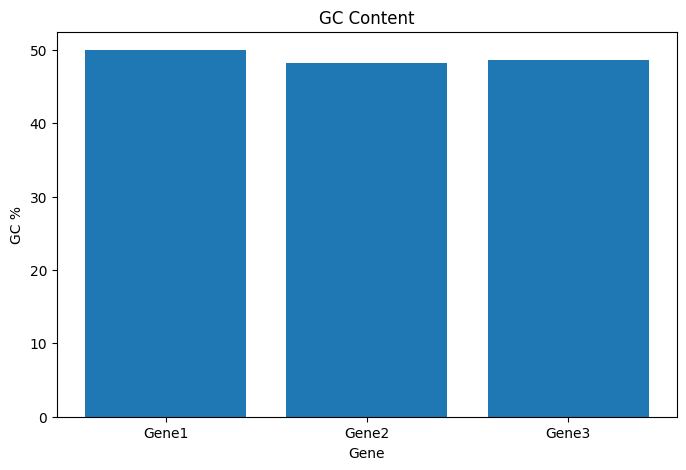

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(
    dashboard["Gene"],
    dashboard["GC %"]
)
plt.title("GC Content")
plt.xlabel("Gene")
plt.ylabel("GC %")
plt.show()

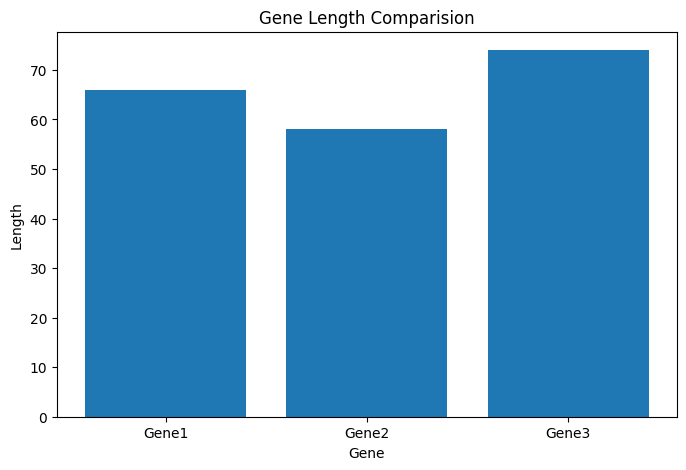

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    dashboard["Gene"],
    dashboard["Length"]
)
plt.title("Gene Length Comparision")
plt.xlabel("Gene")
plt.ylabel("Length")
plt.show()

In [ ]:
gene1_dinuc = dinucleotide_freq(
    sequences["Gene1"])
print(gene1_dinuc)


Counter({'GC': 9, 'CT': 9, 'AT': 8, 'TC': 8, 'CG': 8, 'TA': 8, 'AG': 8, 'GA': 7})


In [ ]:
dinuc_df = pd.DataFrame(
    gene1_dinuc.items(),
    columns=["Dinucleotide","Frequency"]
)
dinuc_df

,Dinucleotide,Frequency
0,AT,8
1,TC,8
2,CG,8
3,GA,7
4,GC,9
5,CT,9
6,TA,8
7,AG,8


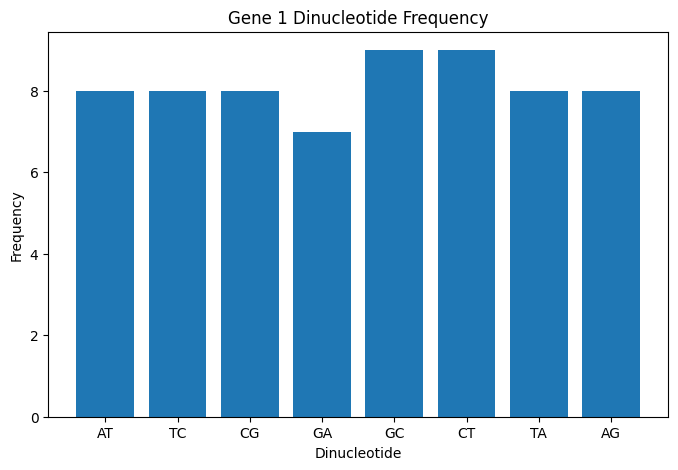

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    dinuc_df["Dinucleotide"],
    dinuc_df["Frequency"]
)
plt.title("Gene 1 Dinucleotide Frequency")
plt.xlabel("Dinucleotide")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("*",40)


* 40
GC Content Dashboard
* 40
    Gene  Length   AT %   GC %
0  Gene1      66  50.00  50.00
1  Gene2      58  51.72  48.28
2  Gene3      74  51.35  48.65
* 40
